# ERA5 vs. SASSIE surface fluxes, Beaufort Sea, autumn 2022

**Question.** How well can ERA5 be trusted for surface radiative and turbulent fluxes in the
open-water / marginal-ice region the SASSIE campaign sampled?

**Approach.** Every 20 min shipboard record from R/V *Woldstad* is matched to the ERA5 grid cell
whose centre is closest to the ship, and to the ERA5 hourly window that contains it. Both series
are then averaged onto the ERA5 hourly grid and differenced.

## Data

| Source | File | Notes |
| --- | --- | --- |
| SASSIE | `SASSIE_Fall_2022_shipboard_MET.nc` | PO.DAAC `SASSIE_L2_SHIPBOARD_METEOROLOGY_V2`, DOI [10.5067/SASSIE-MET2](https://doi.org/10.5067/SASSIE-MET2). 20 min averages, 2022-09-09T01:08Z to 2022-10-01T23:48Z, 1653 records. |
| ERA5 | `../data/barrow` + `data/sassie_gap_{south,west,east}` | Hourly single-level fields, 0.25 deg, mosaicked onto 69.00-73.75 N / 166.25-144.50 W by `era5_sassie_mosaic.py`. |

The CDS `barrow` archive already on disk (70-80 N, 165-150 W) contains only 58 % of the SASSIE ship
track. `download_era5_sassie_gap.py` fetches the three tiles that complete the box - 784 cells, not
the 1760 a whole-box request would re-download - and Section 2 stitches all four together.

## The four fluxes

These are the quantities in Figure 8 of Drushka et al. (2024), *Earth Syst. Sci. Data* **16**,
4209-4242, [doi:10.5194/essd-16-4209-2024](https://doi.org/10.5194/essd-16-4209-2024).

| Flux | SASSIE variable | Instrument / method | ERA5 variable |
| --- | --- | --- | --- |
| Shortwave | `shortwave_radiation` | Kipp & Zonen CMP21 pyranometer, wheelhouse 10 m | `msdwswrf` |
| Longwave | `downwelling_longwave` | Kipp & Zonen CGR4 pyrgeometer, wheelhouse 10 m | `msdwlwrf` |
| Sensible heat | `bulk_sensible_heat_flux` | COARE 3.5 bulk algorithm | `msshf` |
| Latent heat | `bulk_latent_heat_flux` | COARE 3.5 bulk algorithm, RH fixed at 89 % | `mslhf` |

**Radiation is compared as the downwelling component, not the net.** SASSIE carried a pyranometer
and a pyrgeometer but no upward-looking pair, so its net fluxes require an assumed ocean albedo and
emissivity, while the downwelling fluxes are direct measurements. Comparing downwelling isolates
what ERA5's radiation scheme and cloud field actually got wrong, with no assumption bolted on. A
net-longwave comparison in the paper's convention is given at the end as a supplement, with its
assumptions written out.

## Sign conventions

Two conventions are in play and they are **not** mixed within any one panel:

* **Radiation panels** use *positive downward* (into the ocean). Both datasets store downwelling
  radiation this way already, so nothing is flipped.
* **Turbulent panels** use *positive out of the ocean* (upward), matching Figure 8b of the paper and
  the sign actually stored in the SASSIE file. ERA5 defines surface turbulent fluxes positive
  **downward**, so ERA5 is negated: `SH_up = -msshf`, `LH_up = -mslhf`.

The axis label on every panel states which convention it is using.

## Two data caveats found while preparing this

1. `bulk_sensible_heat_flux` and `bulk_latent_heat_flux` carry the `long_name`
   *"...flux into ocean..."* in the PO.DAAC file, but the stored values are positive **out of** the
   ocean. This is verified below from the sign of the air-sea temperature difference, and it agrees
   with Figure 8b of the paper. The `long_name` is wrong; the data are not.
2. `bulk_upwelling_IR` is documented as *"estimated net longwave radiation"* but its values run
   0.08-16.5 (not a W m-2 longwave flux) and it correlates with `bulk_U10` at r = 1.000. It is a
   duplicate of the 10 m wind speed under a longwave name. **It is not used here.** Net longwave on
   the SASSIE side is recomputed from `downwelling_longwave` and `bulk_ocean_temp` instead.

In [1]:

from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

HERE = Path.cwd()
FIG_DIR = HERE / "figures"
FIG_DIR.mkdir(exist_ok=True)

SASSIE_DIR = Path("/Users/andrewbuggee/Documents/Scripps - UCSD/Ocean Visions/SASSIE")
SASSIE_MET = SASSIE_DIR / "SASSIE_Fall_2022_shipboard_MET.nc"
ERA5_CACHE = HERE / "data" / "era5_sassie_box_202209_202210.nc"

DPI = 350
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": DPI, "font.size": 10.5,
                     "axes.grid": True, "grid.alpha": 0.25})

C_ERA5, C_SASSIE, C_RESID = "#1f77b4", "#d62728", "#444444"

STEFAN_BOLTZMANN_W_M2_K4 = 5.670374419e-8
SEAWATER_EMISSIVITY = 0.97          # broadband, Konda et al. (1994); used only in the supplement
FREEZING_POINT_K = 273.15

print(f"SASSIE MET file : {SASSIE_MET}  exists={SASSIE_MET.exists()}")
print(f"ERA5 cache      : {ERA5_CACHE}  exists={ERA5_CACHE.exists()}")

SASSIE MET file : /Users/andrewbuggee/Documents/Scripps - UCSD/Ocean Visions/SASSIE/SASSIE_Fall_2022_shipboard_MET.nc  exists=True
ERA5 cache      : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/sassie_comparison/data/era5_sassie_box_202209_202210.nc  exists=True


## 1. SASSIE shipboard meteorology

The record is a trajectory: `time`, `latitude`, and `longitude` all share the single `time`
dimension, so each row is one 20 min average at one ship position.

In [2]:

sassie_ds = xr.open_dataset(SASSIE_MET)

SASSIE_FIELDS = {
    "swd_w_m2": "shortwave_radiation",            # downwelling SW, positive down
    "lwd_w_m2": "downwelling_longwave",           # downwelling LW, positive down
    "sh_up_w_m2": "bulk_sensible_heat_flux",      # COARE 3.5, positive OUT of ocean
    "lh_up_w_m2": "bulk_latent_heat_flux",        # COARE 3.5, positive OUT of ocean
    "lh_up_low_w_m2": "bulk_latent_heat_flux_low",
    "lh_up_high_w_m2": "bulk_latent_heat_flux_high",
    "sst_c": "bulk_ocean_temp",                   # sea surface temperature, deg C
    "t_air_c": "air_temperature_merged",          # merged air temperature, deg C
    "wspd_m_s": "wspd_average",
}

sassie = pd.DataFrame(
    {"time": pd.to_datetime(sassie_ds["time"].values),
     "lat_deg": sassie_ds["latitude"].values.astype("float64"),
     "lon_deg": sassie_ds["longitude"].values.astype("float64")}
)
for out_name, src_name in SASSIE_FIELDS.items():
    sassie[out_name] = sassie_ds[src_name].values.astype("float64")

print(f"{len(sassie)} records, {sassie.time.min()} -> {sassie.time.max()}")
print(f"lat {sassie.lat_deg.min():.3f} to {sassie.lat_deg.max():.3f} N, "
      f"lon {sassie.lon_deg.min():.3f} to {sassie.lon_deg.max():.3f} E")
sassie[list(SASSIE_FIELDS)].describe().T[["count", "mean", "std", "min", "50%", "max"]]

1653 records, 2022-09-09 01:08:46.199998976 -> 2022-10-01 23:48:46.199923200
lat 69.196 to 73.520 N, lon -165.964 to -144.891 E


,count,mean,std,min,50%,max
swd_w_m2,1580.0,40.164846,63.352592,-3.702576,5.011027,442.821442
lwd_w_m2,1580.0,296.757978,15.309368,219.464859,298.362442,326.984467
sh_up_w_m2,1559.0,23.329225,21.433581,-11.439240,21.067150,112.217842
lh_up_w_m2,1559.0,25.046876,16.243248,-1.163675,23.731550,105.932404
lh_up_low_w_m2,1559.0,14.104270,14.488254,-10.437087,12.650276,88.532059
lh_up_high_w_m2,1559.0,44.070285,20.967333,0.001737,44.794903,136.028992
sst_c,1653.0,1.065676,1.436626,-1.200530,1.111854,6.852154
t_air_c,1630.0,-0.855758,1.825988,-5.858469,-0.976342,4.902665
wspd_m_s,1643.0,7.232053,2.853344,0.379978,7.339997,15.962809


### 1.1 Verifying the turbulent-flux sign convention

If the stored sensible heat flux were positive *into* the ocean, as its `long_name` claims, it
would have to be negative whenever the ocean is warmer than the air. It is not: the correlation
below is strongly positive against `SST - T_air`, so positive means *out of the ocean*.

In [3]:

delta_t_c = sassie["sst_c"] - sassie["t_air_c"]
ok = delta_t_c.notna() & sassie["sh_up_w_m2"].notna()

r_sh_dt = np.corrcoef(delta_t_c[ok], sassie.loc[ok, "sh_up_w_m2"])[0, 1]
frac_ocean_warmer = float((delta_t_c[ok] > 0).mean())

print(f"corr( SH , SST - T_air )        = {r_sh_dt:+.3f}")
print(f"fraction of time ocean warmer   = {frac_ocean_warmer:.1%}")
print(f"mean SH = {sassie['sh_up_w_m2'].mean():+.1f} W m-2, "
      f"mean LH = {sassie['lh_up_w_m2'].mean():+.1f} W m-2")
print()
print("Ocean warmer than air most of the campaign AND SH positive AND SH rising with SST - T_air")
print("=> the stored sign is POSITIVE OUT OF THE OCEAN. The long_name 'into ocean' is wrong.")

# The documented-as-longwave field that is really wind speed (caveat 2 in the header).
uir = sassie_ds["bulk_upwelling_IR"].values.astype("float64")
u10 = sassie_ds["bulk_U10"].values.astype("float64")
m = np.isfinite(uir) & np.isfinite(u10)
print(f"\ncorr( bulk_upwelling_IR , bulk_U10 ) = {np.corrcoef(uir[m], u10[m])[0, 1]:.6f}"
      f"   range of bulk_upwelling_IR = {np.nanmin(uir):.2f} to {np.nanmax(uir):.2f}")

corr( SH , SST - T_air )        = +0.917
fraction of time ocean warmer   = 84.7%
mean SH = +23.3 W m-2, mean LH = +25.0 W m-2

Ocean warmer than air most of the campaign AND SH positive AND SH rising with SST - T_air
=> the stored sign is POSITIVE OUT OF THE OCEAN. The long_name 'into ocean' is wrong.

corr( bulk_upwelling_IR , bulk_U10 ) = 0.999995   range of bulk_upwelling_IR = 0.08 to 16.48


## 2. ERA5 over the ship-track box

The comparison needs ERA5 on 69.00-73.75 N, 166.25-144.50 W: the ship track
(69.20-73.52 N, 165.96-144.89 W) with one grid cell of margin. That box is assembled from four
CDS archives that tile it exactly, with no overlap and no seam:

|  | 166.25-165.25 W | 165.00-150.00 W | 149.75-144.50 W |
| --- | --- | --- | --- |
| **73.75-70.00 N** | `sassie_gap_west` | `barrow` (already on disk) | `sassie_gap_east` |
| **69.75-69.00 N** | `sassie_gap_south` | `sassie_gap_south` | `sassie_gap_south` |

`barrow` supplies 976 of the 1760 cells and predates this analysis. The other 784 come from
`download_era5_sassie_gap.py`, which pulls just the three gap tiles for 2022-09-08 to 2022-10-02 in
nine CDS requests rather than re-fetching the whole box. `era5_sassie_mosaic.load_sassie_box()`
merges them and asserts the tiling is exact and hole-free before returning.

If the gap tiles are not on disk, the loader below falls back to the single-box cache written by
`fetch_era5_sassie_box.py` from the NSF NCAR S3 mirror. Both routes give the same ERA5 fields on
the same 0.25 deg grid; the CDS mosaic is preferred because it carries the full 35-variable set and
matches the rest of the archive.

**ERA5 hourly mean-rate convention.** A `mean_*` flux stamped at valid time *t* is the average over
the hour **ending** at *t*, i.e. the window (*t*-1 h, *t*]. Every temporal match below respects
that.

In [4]:

ERA5_START_DATE, ERA5_END_DATE = "2022-09-08", "2022-10-02"

sys.path.insert(0, str(HERE))

try:
    from era5_sassie_mosaic import load_sassie_box

    era5 = load_sassie_box(ERA5_START_DATE, ERA5_END_DATE)
    era5_source = "CDS mosaic (barrow + three sassie_gap_* tiles)"
except FileNotFoundError as exc:
    print(f"Mosaic unavailable: {exc}")
    print("Falling back to the NSF NCAR S3 single-box cache.")
    if not ERA5_CACHE.exists():
        import fetch_era5_sassie_box
        fetch_era5_sassie_box.main()
    era5 = xr.open_dataset(ERA5_CACHE)
    era5_source = "NSF NCAR S3 mirror (single box)"

era5 = era5.sortby("valid_time")

era5_lat_deg = era5["latitude"].values.astype("float64")
era5_lon_deg = era5["longitude"].values.astype("float64")
era5_time = pd.to_datetime(era5["valid_time"].values)

print(f"\nsource      : {era5_source}")
print(f"grid        : {era5_lat_deg.size} lat x {era5_lon_deg.size} lon, "
      f"{abs(np.diff(era5_lat_deg)).mean():.3f} deg lat / "
      f"{abs(np.diff(era5_lon_deg)).mean():.3f} deg lon")
print(f"extent      : {era5_lat_deg.min():.2f}-{era5_lat_deg.max():.2f} N, "
      f"{era5_lon_deg.min():.2f}-{era5_lon_deg.max():.2f} E")
print(f"time        : {era5_time[0]} -> {era5_time[-1]}, "
      f"step {pd.Series(era5_time).diff().mode()[0]}")
print(f"variables   : {len(era5.data_vars)}")

tiling check: {'barrow': 976, 'sassie_gap_south': 352, 'sassie_gap_west': 80, 'sassie_gap_east': 352, 'TOTAL': 1760}
  barrow              16 lat x  61 lon x  600 h from 3 file(s)
  sassie_gap_south     4 lat x  88 lon x  600 h from 3 file(s)
  sassie_gap_west     16 lat x   5 lon x  600 h from 3 file(s)
  sassie_gap_east     16 lat x  22 lon x  600 h from 3 file(s)
  merged             20 lat x 88 lon x 600 h, 35 variables, no holes

source      : CDS mosaic (barrow + three sassie_gap_* tiles)
grid        : 20 lat x 88 lon, 0.250 deg lat / 0.250 deg lon
extent      : 69.00-73.75 N, -166.25--144.50 E
time        : 2022-09-08 00:00:00 -> 2022-10-02 23:00:00, step 0 days 01:00:00
variables   : 35


## 3. Collocation

**Space.** ERA5 sits on a separable regular lat/lon grid, so the closest cell centre in great-circle
distance is found by taking the nearest latitude and the nearest longitude independently. Each
20 min record gets its own cell, so the match follows the ship as it steams.

**Time.** Each record is assigned to the ERA5 window that contains it, `ceil` to the next whole
hour, consistent with the hour-ending convention above.

**Aggregation.** SASSIE records sharing an ERA5 hour (normally three) are averaged, and the ERA5
values collocated to each of those records are averaged with them. Hours holding fewer than
`MIN_RECORDS_PER_HOUR` valid records are dropped, so a single 20 min sample never stands in for a
whole hour.

**Land contamination.** The nearest cell to a record near the Alaskan coast can be a land cell,
where ERA5's surface fluxes describe tundra rather than ocean. Cells with no ERA5 `sst` are flagged
and excluded.

In [5]:

MIN_RECORDS_PER_HOUR = 2

# ERA5 fields to carry through, in ERA5's native positive-downward convention.
ERA5_FIELDS = ["msdwswrf", "msnswrf", "msdwlwrf", "msnlwrf", "msshf", "mslhf", "siconc", "sst"]


def nearest_grid_index(values_deg: np.ndarray, axis_deg: np.ndarray) -> np.ndarray:
    """Index of the closest coordinate on a 1-D axis, for each value. Shape (n,)."""
    return np.abs(values_deg[:, None] - axis_deg[None, :]).argmin(axis=1)  # (n, n_axis) -> (n,)


lat_idx = nearest_grid_index(sassie["lat_deg"].to_numpy(), era5_lat_deg)
lon_idx = nearest_grid_index(sassie["lon_deg"].to_numpy(), era5_lon_deg)

sassie["era5_lat_deg"] = era5_lat_deg[lat_idx]
sassie["era5_lon_deg"] = era5_lon_deg[lon_idx]
sassie["era5_hour"] = sassie["time"].dt.ceil("1h")

time_idx = pd.Index(era5_time).get_indexer(sassie["era5_hour"])
if (time_idx < 0).any():
    raise ValueError(f"{int((time_idx < 0).sum())} records fall outside the cached ERA5 hours.")

# Point-wise (time, lat, lon) pull: one ERA5 value per shipboard record.
for name in ERA5_FIELDS:
    sassie[f"era5_{name}"] = era5[name].values[time_idx, lat_idx, lon_idx].astype("float64")

# Great-circle offset between the ship and the cell centre it was matched to.
EARTH_RADIUS_KM = 6371.0
d_lat_rad = np.radians(sassie["era5_lat_deg"] - sassie["lat_deg"])
d_lon_rad = np.radians(sassie["era5_lon_deg"] - sassie["lon_deg"])
mean_lat_rad = np.radians(0.5 * (sassie["era5_lat_deg"] + sassie["lat_deg"]))
sassie["match_distance_km"] = EARTH_RADIUS_KM * np.hypot(
    d_lat_rad, d_lon_rad * np.cos(mean_lat_rad)
)

is_land = ~np.isfinite(sassie["era5_sst"])
print(f"records                        : {len(sassie)}")
print(f"unique ERA5 cells visited      : {len(set(zip(lat_idx, lon_idx)))}")
print(f"match distance (km)            : median {sassie.match_distance_km.median():.2f}, "
      f"max {sassie.match_distance_km.max():.2f}")
print(f"records matched to a land cell : {int(is_land.sum())} ({is_land.mean():.2%}) - excluded")
print(f"ERA5 sea-ice cover at match    : median {sassie.era5_siconc.median():.3f}, "
      f"max {sassie.era5_siconc.max():.3f}")

sassie = sassie.loc[~is_land].copy()

records                        : 1653
unique ERA5 cells visited      : 194
match distance (km)            : median 7.12, max 14.37
records matched to a land cell : 0 (0.00%) - excluded
ERA5 sea-ice cover at match    : median 0.000, max 0.056


In [6]:

# --- Put both datasets in the convention used by each figure --------------------------
# Radiation: positive DOWNWARD (unchanged on both sides).
sassie["era5_swd_w_m2"] = sassie["era5_msdwswrf"]
sassie["era5_lwd_w_m2"] = sassie["era5_msdwlwrf"]
# Turbulent: positive OUT OF THE OCEAN. ERA5 is positive downward, so negate.
sassie["era5_sh_up_w_m2"] = -sassie["era5_msshf"]
sassie["era5_lh_up_w_m2"] = -sassie["era5_mslhf"]

PAIR_COLUMNS = ["swd_w_m2", "lwd_w_m2", "sh_up_w_m2", "lh_up_w_m2"]
CARRY_COLUMNS = ["lat_deg", "lon_deg", "sst_c", "t_air_c", "wspd_m_s",
                 "lh_up_low_w_m2", "lh_up_high_w_m2",
                 "era5_siconc", "era5_sst", "era5_msnlwrf", "era5_msdwlwrf",
                 "match_distance_km"]

agg_columns = PAIR_COLUMNS + [f"era5_{c}" for c in PAIR_COLUMNS] + CARRY_COLUMNS
hourly = sassie.groupby("era5_hour")[agg_columns].mean()
hourly["n_records"] = sassie.groupby("era5_hour")["swd_w_m2"].size()
hourly = hourly.loc[hourly["n_records"] >= MIN_RECORDS_PER_HOUR]

for column in PAIR_COLUMNS:
    hourly[f"resid_{column}"] = hourly[f"era5_{column}"] - hourly[column]

print(f"{len(hourly)} matched hours, {hourly.index.min()} -> {hourly.index.max()}")
print(f"records per hour: {hourly.n_records.value_counts().sort_index().to_dict()}")
hourly.head()

551 matched hours, 2022-09-09 02:00:00 -> 2022-10-02 00:00:00
records per hour: {3: 551}


,swd_w_m2,lwd_w_m2,sh_up_w_m2,lh_up_w_m2,era5_swd_w_m2,era5_lwd_w_m2,era5_sh_up_w_m2,era5_lh_up_w_m2,lat_deg,lon_deg,...,era5_siconc,era5_sst,era5_msnlwrf,era5_msdwlwrf,match_distance_km,n_records,resid_swd_w_m2,resid_lwd_w_m2,resid_sh_up_w_m2,resid_lh_up_w_m2
era5_hour,,,,,,,,,,,,,,,,,,,,,
2022-09-09 02:00:00,NaN,NaN,NaN,NaN,104.416667,311.323527,6.186279,6.067383,72.252157,-150.678416,...,0.0,275.497396,-10.816594,311.323527,2.046809,3,NaN,NaN,NaN,NaN
2022-09-09 03:00:00,NaN,NaN,NaN,NaN,74.572917,307.574809,6.899821,5.058350,72.251147,-150.196991,...,0.0,275.473307,-14.078288,307.574809,2.316862,3,NaN,NaN,NaN,NaN
2022-09-09 04:00:00,NaN,NaN,NaN,NaN,35.328125,312.574493,5.873291,4.118164,72.289556,-149.981491,...,0.0,275.390625,-8.833740,312.574493,4.809147,3,NaN,NaN,NaN,NaN
2022-09-09 05:00:00,NaN,NaN,NaN,NaN,12.093750,308.671936,3.938314,3.849202,72.383586,-149.980382,...,0.0,274.801432,-10.707113,308.671936,11.744595,3,NaN,NaN,NaN,NaN
2022-09-09 06:00:00,NaN,NaN,NaN,NaN,0.093750,310.627197,1.851074,3.081787,72.451256,-149.980687,...,0.0,274.506836,-7.793945,310.627197,5.463575,3,NaN,NaN,NaN,NaN


### 3.1 Where the comparison happens

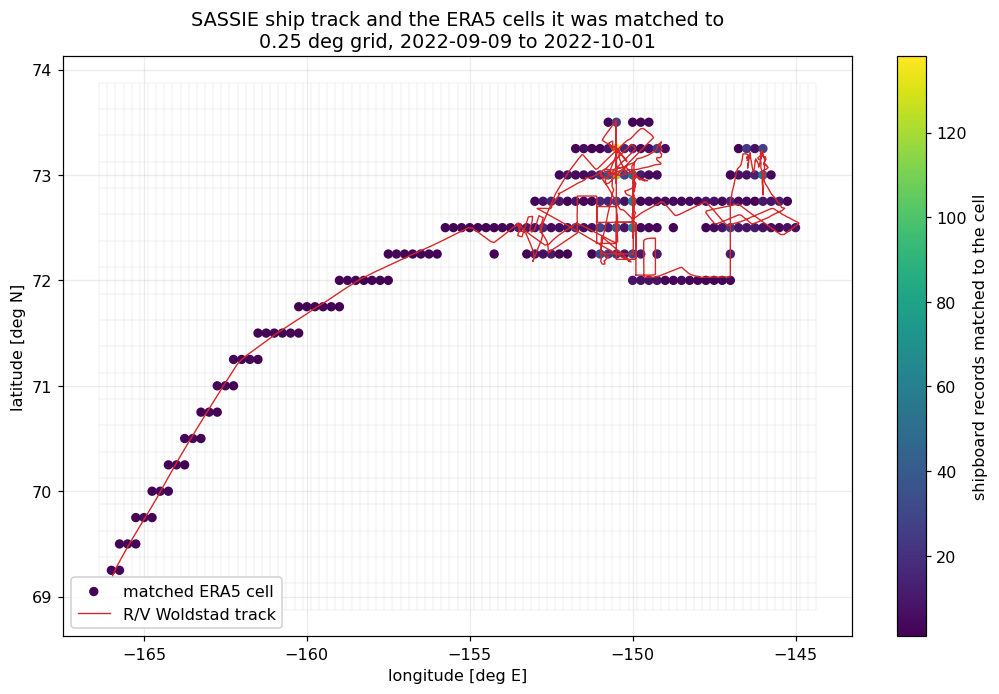

In [7]:

fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)

lon_edges = np.append(era5_lon_deg - 0.125, era5_lon_deg[-1] + 0.125)
lat_edges = np.append(era5_lat_deg + 0.125, era5_lat_deg[-1] - 0.125)
ax.vlines(lon_edges, lat_edges.min(), lat_edges.max(), lw=0.25, color="0.85", zorder=0)
ax.hlines(lat_edges, lon_edges.min(), lon_edges.max(), lw=0.25, color="0.85", zorder=0)

cell_counts = (sassie.groupby(["era5_lat_deg", "era5_lon_deg"]).size()
               .rename("n").reset_index())
sc = ax.scatter(cell_counts.era5_lon_deg, cell_counts.era5_lat_deg, s=26,
                c=cell_counts.n, cmap="viridis", zorder=2,
                label="matched ERA5 cell")
ax.plot(sassie.lon_deg, sassie.lat_deg, lw=0.9, color=C_SASSIE, zorder=3,
        label="R/V Woldstad track")

fig.colorbar(sc, ax=ax, label="shipboard records matched to the cell")
ax.set_xlabel("longitude [deg E]")
ax.set_ylabel("latitude [deg N]")
ax.set_title("SASSIE ship track and the ERA5 cells it was matched to\n"
             "0.25 deg grid, 2022-09-09 to 2022-10-01")
ax.set_aspect(1.0 / np.cos(np.radians(72.0)))
ax.legend(loc="lower left", framealpha=0.9)
fig.savefig(FIG_DIR / "sassie_era5_collocation_map.png", bbox_inches="tight")
plt.show()

## 4. Comparison figures

Each figure has the layout requested: ERA5 and SASSIE on one axis, their difference below.

The residual is always **ERA5 minus SASSIE**, so positive means ERA5 is high relative to the ship.
The lower panel also carries a 24 h running mean, which separates a persistent offset from
event-scale scatter, and the panel text reports:

* **bias** - mean of the residual, the systematic part;
* **RMSD** - root mean square difference, total disagreement;
* **cRMSD** - centred RMSD (RMSD with the bias removed), the random part;
* **r** - Pearson correlation of the two series.

In [8]:

def comparison_statistics(era5_values: np.ndarray, sassie_values: np.ndarray) -> dict:
    """Bias / RMSD / centred RMSD / correlation for one matched pair of series."""
    ok = np.isfinite(era5_values) & np.isfinite(sassie_values)
    e, s = era5_values[ok], sassie_values[ok]
    if e.size < 3:
        return {"n": int(e.size), "bias": np.nan, "rmsd": np.nan,
                "crmsd": np.nan, "r": np.nan, "sassie_mean": np.nan}
    residual = e - s
    return {
        "n": int(e.size),
        "bias": float(residual.mean()),
        "rmsd": float(np.sqrt((residual ** 2).mean())),
        "crmsd": float(residual.std(ddof=1)),
        "r": float(np.corrcoef(e, s)[0, 1]),
        "sassie_mean": float(s.mean()),
    }


def plot_flux_comparison(column: str, title: str, ylabel: str,
                         filename: str, band_columns: tuple[str, str] | None = None,
                         subset_mask: pd.Series | None = None,
                         subset_label: str = ""):
    """Two-panel ERA5 vs SASSIE figure: series on top, ERA5 - SASSIE below."""
    sassie_values = hourly[column].to_numpy()
    era5_values = hourly[f"era5_{column}"].to_numpy()
    residual = hourly[f"resid_{column}"]
    times = hourly.index

    stats = comparison_statistics(era5_values, sassie_values)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(12.5, 7.4), sharex=True, constrained_layout=True,
        gridspec_kw={"height_ratios": [2.0, 1.0]},
    )

    if band_columns is not None:
        ax_top.fill_between(times, hourly[band_columns[0]], hourly[band_columns[1]],
                            color=C_SASSIE, alpha=0.18, lw=0,
                            label="SASSIE RH 70-100 % bound")
    ax_top.plot(times, sassie_values, lw=1.1, color=C_SASSIE, label="SASSIE (R/V Woldstad)")
    ax_top.plot(times, era5_values, lw=1.1, color=C_ERA5, label="ERA5 nearest cell")
    ax_top.set_ylabel(ylabel)
    ax_top.set_title(title)
    ax_top.legend(loc="upper left", ncols=3, framealpha=0.9)

    ax_bot.axhline(0.0, color="k", lw=0.8)
    ax_bot.plot(times, residual, lw=0.9, color=C_RESID, alpha=0.75, label="hourly residual")
    ax_bot.plot(times, residual.rolling(24, center=True, min_periods=12).mean(),
                lw=2.0, color="#ff7f0e", label="24 h running mean")
    ax_bot.axhline(stats["bias"], color=C_ERA5, lw=1.2, ls="--",
                   label=f"bias {stats['bias']:+.1f}")
    ax_bot.set_ylabel(f"ERA5 - SASSIE\n{ylabel}")
    ax_bot.set_xlabel("date (UTC), 2022")
    ax_bot.legend(loc="upper left", ncols=3, framealpha=0.9)

    summary = (f"n = {stats['n']} h{subset_label}\n"
               f"bias  = {stats['bias']:+7.1f} W m$^{{-2}}$\n"
               f"RMSD  = {stats['rmsd']:7.1f} W m$^{{-2}}$\n"
               f"cRMSD = {stats['crmsd']:7.1f} W m$^{{-2}}$\n"
               f"r     = {stats['r']:7.3f}")
    ax_bot.text(0.995, 0.05, summary, transform=ax_bot.transAxes,
                ha="right", va="bottom", family="monospace", fontsize=9,
                bbox={"boxstyle": "round,pad=0.4", "fc": "white", "ec": "0.6", "alpha": 0.92})

    ax_bot.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax_bot.xaxis.set_minor_locator(mdates.DayLocator())

    fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()
    return stats

### 4.1 Downwelling shortwave

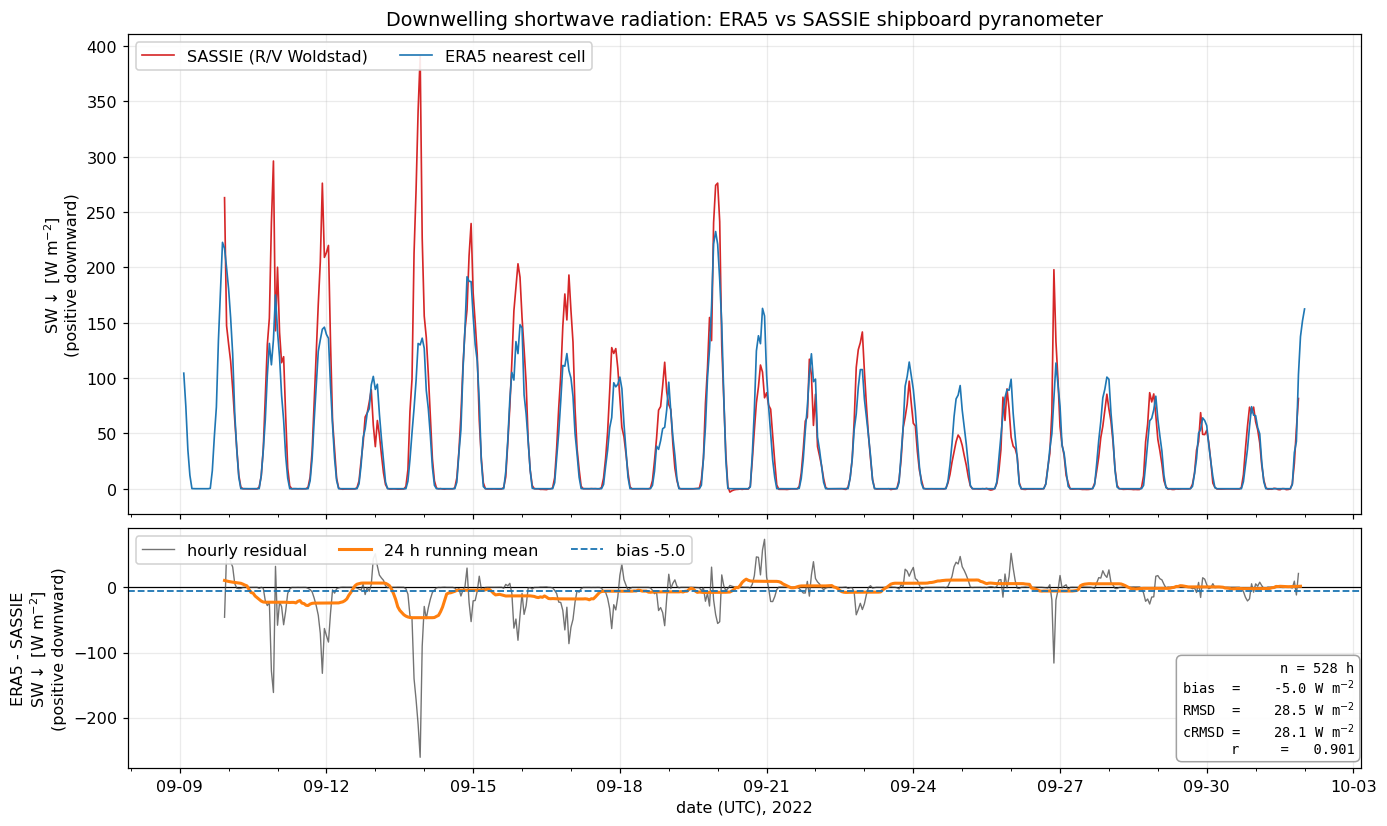

Daylight hours only (SASSIE SW down > 20 W m-2), n = 224:
  bias  -11.7 W m-2  (-12.6 % of the 93.0 W m-2 daylight mean)
  RMSD  43.7 W m-2    r = 0.778


In [9]:

stats_swd = plot_flux_comparison(
    column="swd_w_m2",
    title="Downwelling shortwave radiation: ERA5 vs SASSIE shipboard pyranometer",
    ylabel="SW$\\downarrow$ [W m$^{-2}$]\n(positive downward)",
    filename="era5_vs_sassie_shortwave.png",
)

# Night dominates the record by late September, and zeros on both sides inflate r.
# Daylight-only statistics are the honest number for the shortwave scheme.
daylight = hourly["swd_w_m2"] > 20.0
stats_swd_day = comparison_statistics(
    hourly.loc[daylight, "era5_swd_w_m2"].to_numpy(),
    hourly.loc[daylight, "swd_w_m2"].to_numpy(),
)
print(f"Daylight hours only (SASSIE SW down > 20 W m-2), n = {stats_swd_day['n']}:")
print(f"  bias  {stats_swd_day['bias']:+.1f} W m-2  "
      f"({100 * stats_swd_day['bias'] / stats_swd_day['sassie_mean']:+.1f} % of the "
      f"{stats_swd_day['sassie_mean']:.1f} W m-2 daylight mean)")
print(f"  RMSD  {stats_swd_day['rmsd']:.1f} W m-2    r = {stats_swd_day['r']:.3f}")

### 4.2 Downwelling longwave

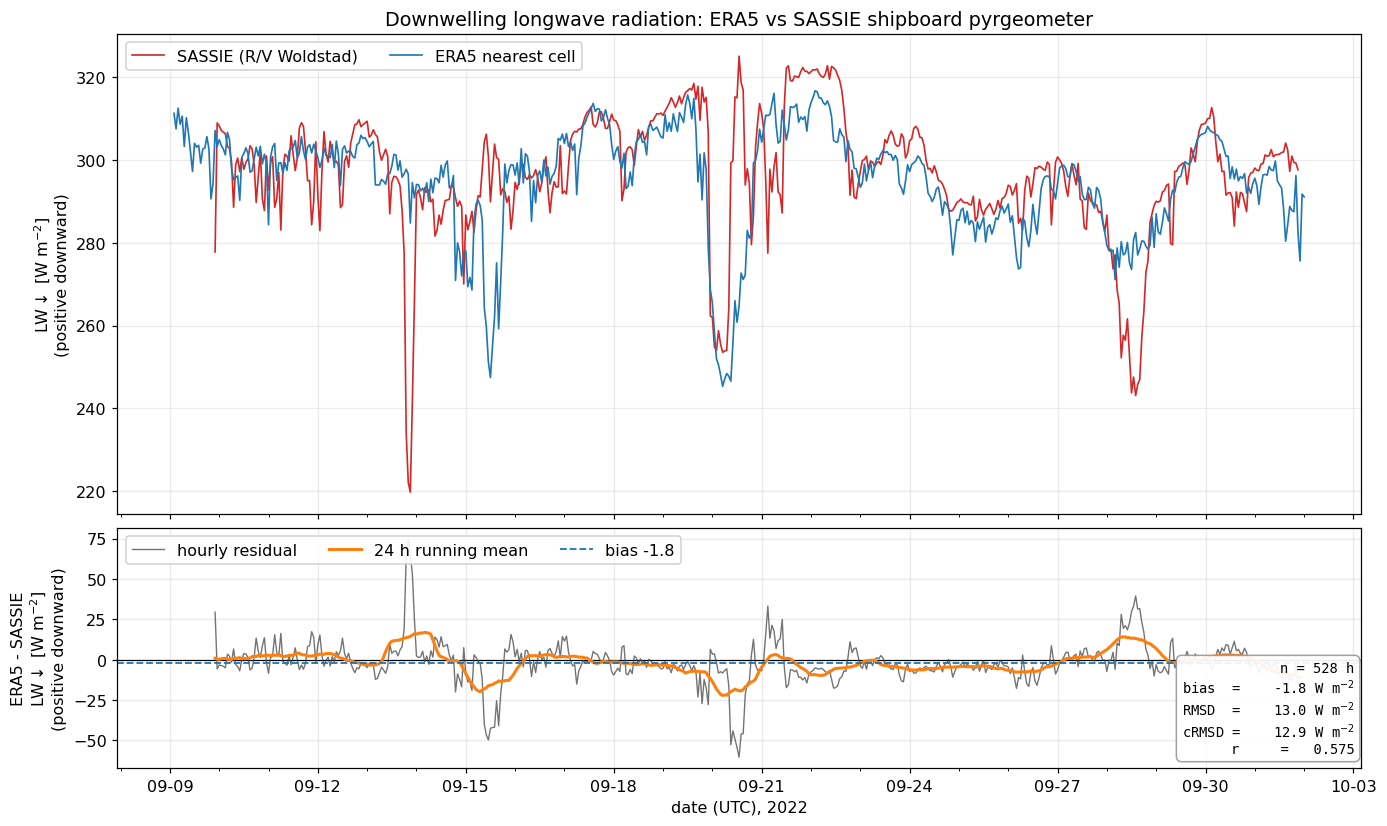

In [10]:

stats_lwd = plot_flux_comparison(
    column="lwd_w_m2",
    title="Downwelling longwave radiation: ERA5 vs SASSIE shipboard pyrgeometer",
    ylabel="LW$\\downarrow$ [W m$^{-2}$]\n(positive downward)",
    filename="era5_vs_sassie_longwave.png",
)

### 4.3 Sensible heat flux

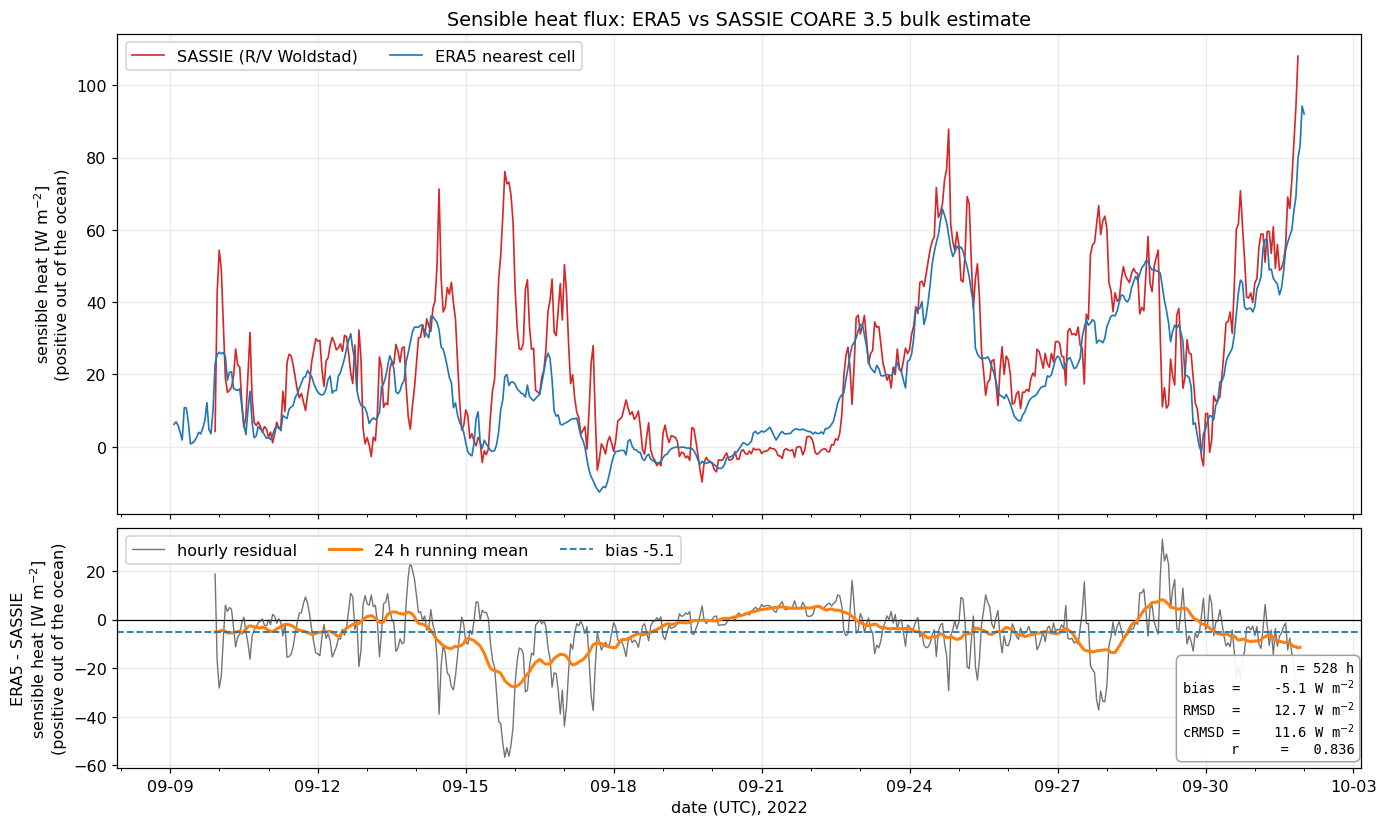

In [11]:

stats_sh = plot_flux_comparison(
    column="sh_up_w_m2",
    title="Sensible heat flux: ERA5 vs SASSIE COARE 3.5 bulk estimate",
    ylabel="sensible heat [W m$^{-2}$]\n(positive out of the ocean)",
    filename="era5_vs_sassie_sensible.png",
)

### 4.4 Latent heat flux

The shaded band is the SASSIE uncertainty from relative humidity: the RH sensors failed, so COARE
was run at a fixed RH = 89 % with bounds from RH = 70 % and RH = 100 % (Persson et al., 2018),
carried in the file as `bulk_latent_heat_flux_low` / `_high`. Where the ERA5 line sits inside that
band, the two are not distinguishable given what SASSIE could measure.

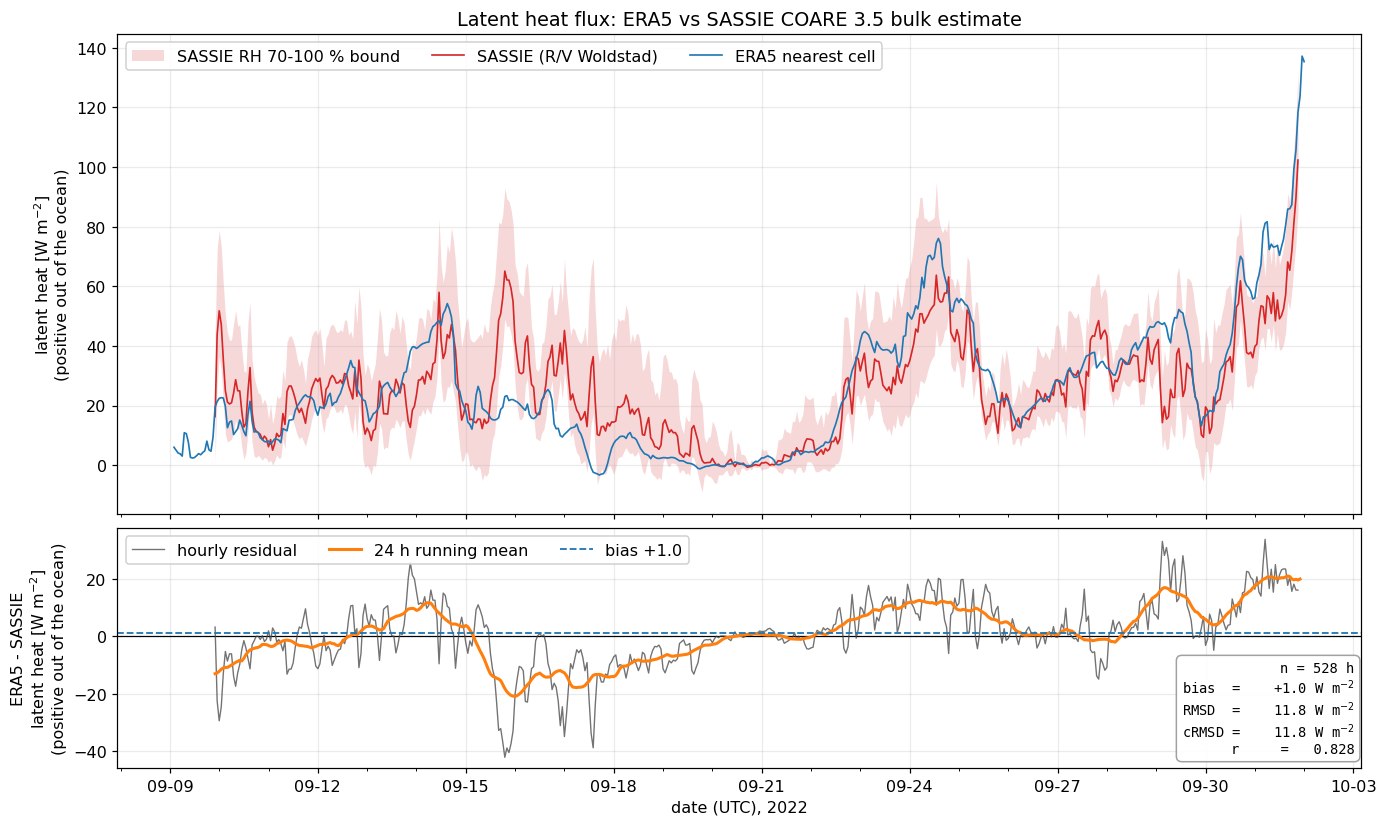

ERA5 latent heat lies inside the SASSIE RH uncertainty band 79.3% of matched hours.


In [12]:

stats_lh = plot_flux_comparison(
    column="lh_up_w_m2",
    title="Latent heat flux: ERA5 vs SASSIE COARE 3.5 bulk estimate",
    ylabel="latent heat [W m$^{-2}$]\n(positive out of the ocean)",
    filename="era5_vs_sassie_latent.png",
    band_columns=("lh_up_low_w_m2", "lh_up_high_w_m2"),
)

inside_band = ((hourly["era5_lh_up_w_m2"] >= hourly["lh_up_low_w_m2"]) &
               (hourly["era5_lh_up_w_m2"] <= hourly["lh_up_high_w_m2"]))
print(f"ERA5 latent heat lies inside the SASSIE RH uncertainty band "
      f"{inside_band.mean():.1%} of matched hours.")

## 5. Summary

`bias` is mean(ERA5 - SASSIE); `RMSD` is total disagreement; `cRMSD` is RMSD with the bias removed,
i.e. the part that is not a constant offset. `bias %` normalises the bias by the mean magnitude of
the SASSIE series, so it is only meaningful where that mean is well away from zero.

In [13]:

summary_rows = {
    "SW down (pos. down)": stats_swd,
    "SW down, daylight only": stats_swd_day,
    "LW down (pos. down)": stats_lwd,
    "Sensible (pos. up)": stats_sh,
    "Latent (pos. up)": stats_lh,
}
summary = pd.DataFrame(summary_rows).T
summary["bias %"] = 100.0 * summary["bias"] / summary["sassie_mean"].abs()
summary = summary[["n", "sassie_mean", "bias", "bias %", "rmsd", "crmsd", "r"]]
summary.columns = ["n hours", "SASSIE mean [W m-2]", "bias [W m-2]", "bias [%]",
                   "RMSD [W m-2]", "cRMSD [W m-2]", "r"]
summary.round({"SASSIE mean [W m-2]": 1, "bias [W m-2]": 1, "bias [%]": 1,
               "RMSD [W m-2]": 1, "cRMSD [W m-2]": 1, "r": 3})

,n hours,SASSIE mean [W m-2],bias [W m-2],bias [%],RMSD [W m-2],cRMSD [W m-2],r
SW down (pos. down),528.0,40.4,-5.0,-12.3,28.5,28.1,0.901
"SW down, daylight only",224.0,93.0,-11.7,-12.6,43.7,42.2,0.778
LW down (pos. down),528.0,296.8,-1.8,-0.6,13.0,12.9,0.575
Sensible (pos. up),528.0,23.3,-5.1,-21.7,12.7,11.6,0.836
Latent (pos. up),528.0,25.1,1.0,4.1,11.8,11.8,0.828


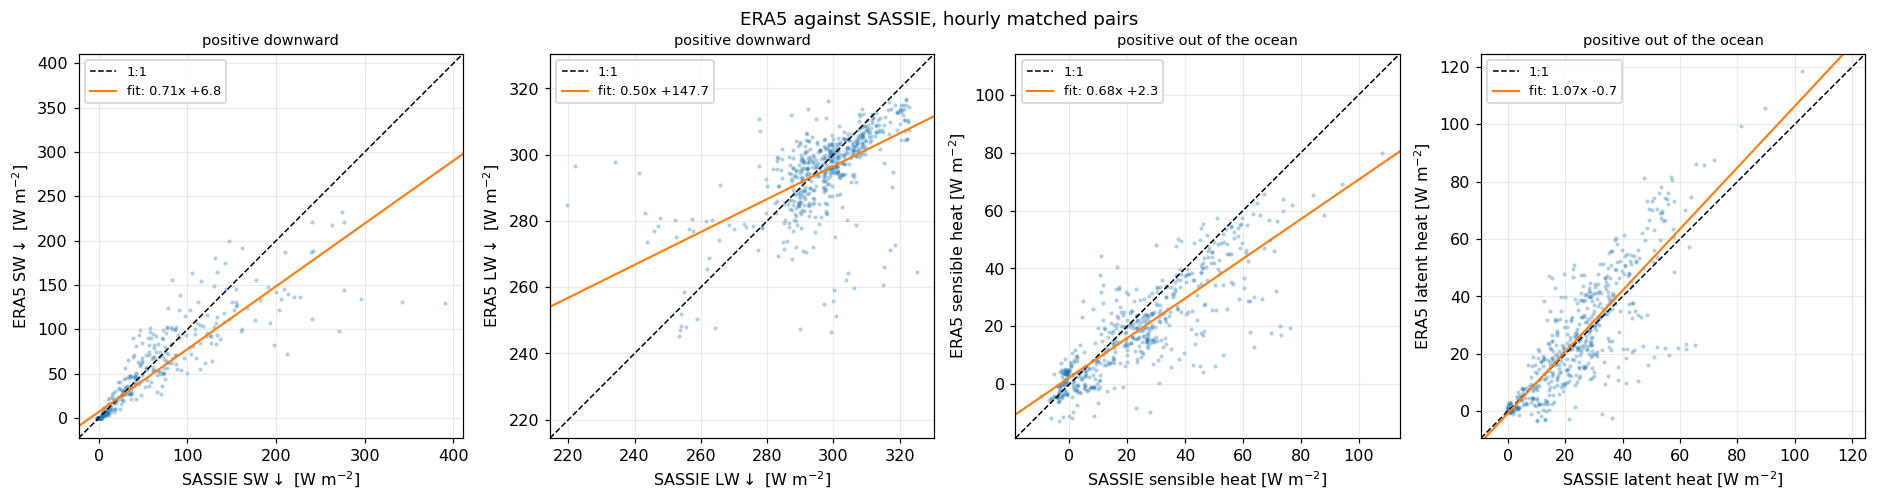

In [14]:

# Scatter view of the same four comparisons: one-to-one line plus the least-squares fit.
PANELS = [
    ("swd_w_m2", "SW$\\downarrow$", "positive downward"),
    ("lwd_w_m2", "LW$\\downarrow$", "positive downward"),
    ("sh_up_w_m2", "sensible heat", "positive out of the ocean"),
    ("lh_up_w_m2", "latent heat", "positive out of the ocean"),
]

fig, axes = plt.subplots(1, 4, figsize=(17.0, 4.4), constrained_layout=True)
for ax, (column, label, convention) in zip(axes, PANELS):
    s = hourly[column].to_numpy()
    e = hourly[f"era5_{column}"].to_numpy()
    ok = np.isfinite(s) & np.isfinite(e)
    ax.scatter(s[ok], e[ok], s=7, alpha=0.35, color=C_ERA5, lw=0)

    lo = float(min(s[ok].min(), e[ok].min()))
    hi = float(max(s[ok].max(), e[ok].max()))
    pad = 0.05 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1.0, label="1:1")

    slope, intercept = np.polyfit(s[ok], e[ok], 1)
    ax.plot([lo - pad, hi + pad],
            np.polyval([slope, intercept], [lo - pad, hi + pad]),
            color="#ff7f0e", lw=1.4,
            label=f"fit: {slope:.2f}x {intercept:+.1f}")

    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal")
    ax.set_xlabel(f"SASSIE {label} [W m$^{{-2}}$]")
    ax.set_ylabel(f"ERA5 {label} [W m$^{{-2}}$]")
    ax.set_title(convention, fontsize=9.5)
    ax.legend(loc="upper left", fontsize=8.5, framealpha=0.9)

fig.suptitle("ERA5 against SASSIE, hourly matched pairs", fontsize=12)
fig.savefig(FIG_DIR / "era5_vs_sassie_scatter.png", bbox_inches="tight")
plt.show()

## 6. Supplement: net longwave, in the convention of the paper's Figure 8c

Figure 8c of Drushka et al. (2024) plots *net* radiation, not downwelling. SASSIE has no
upward-looking pyrgeometer, so its net longwave has to be reconstructed from the measured
downwelling flux and the bulk sea surface temperature, using a graybody sea surface:

$$LW\uparrow = \varepsilon\,\sigma\,T_{sst}^{4} + (1-\varepsilon)\,LW\downarrow,
\qquad
LW_{net,\downarrow} = LW\downarrow - LW\uparrow = \varepsilon\,\bigl(LW\downarrow - \sigma\,T_{sst}^{4}\bigr)$$

with $\varepsilon = 0.97$, the broadband seawater emissivity used inside COARE 3.5. **This is an
assumption, not a measurement**, and it is the reason the downwelling comparison above is the
primary result.

The magnitude of the assumption is worth stating. A common alternative that drops the reflected
term, $LW_{net,\downarrow} = LW\downarrow - \varepsilon\,\sigma\,T_{sst}^{4}$, is used in the
compiled spreadsheet accompanying this dataset and gives a net longwave about 9 W m$^{-2}$ less
negative. Both are computed below so the choice is visible rather than buried.

ERA5's net longwave (`msnlwrf`) needs no reconstruction: it is a model diagnostic with its own
skin temperature and emissivity, and it is already positive downward.

SASSIE net longwave, positive downward [W m-2]
  graybody with reflection (eps = 0.97) : mean -23.12
  reflection omitted                       : mean -14.22
  difference between the two conventions   : -8.90
ERA5 msnlwrf                               : mean -23.52


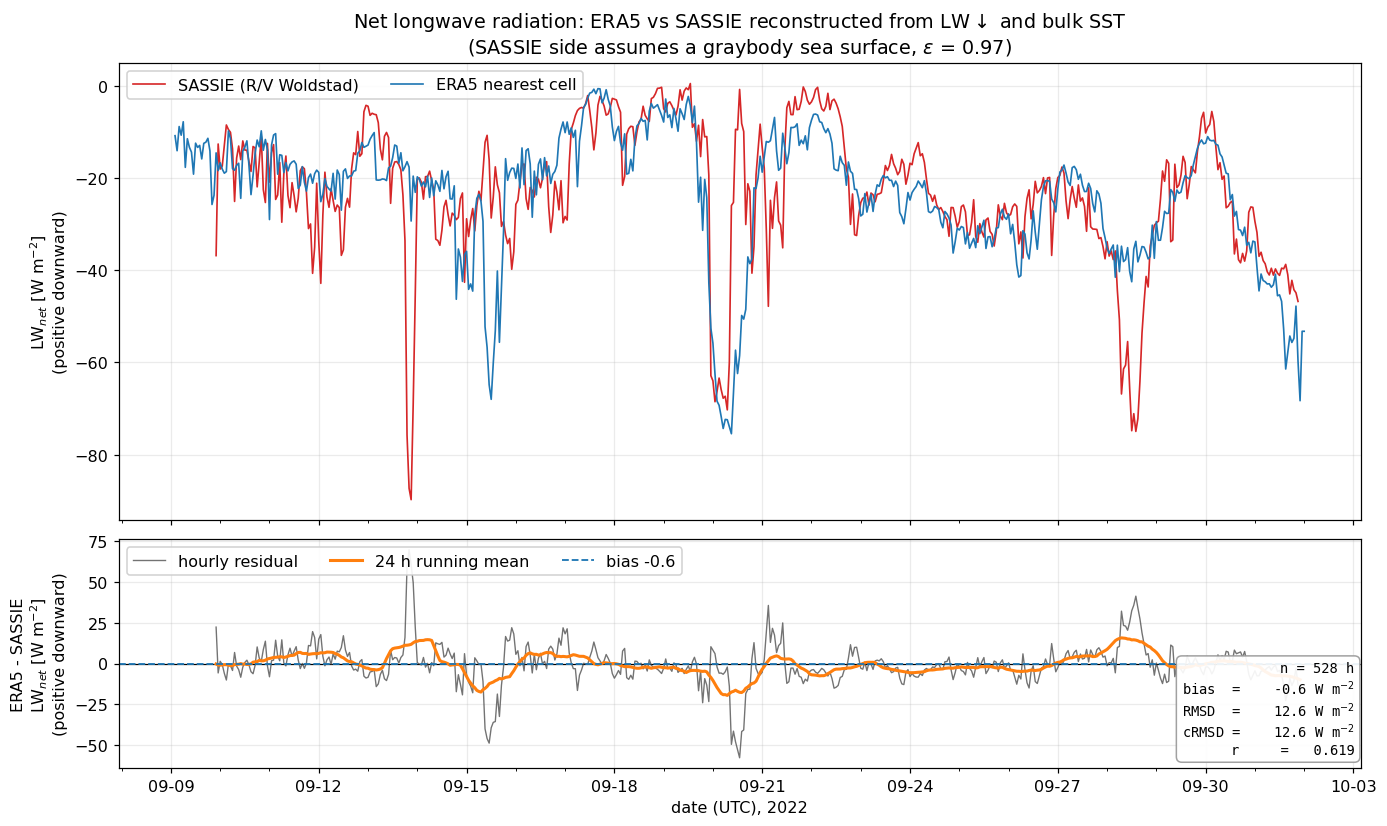

In [15]:

sst_k = hourly["sst_c"] + FREEZING_POINT_K
sigma_t4_w_m2 = STEFAN_BOLTZMANN_W_M2_K4 * sst_k ** 4

# Graybody form, including the reflected downwelling term (COARE 3.5 convention).
hourly["lw_net_down_w_m2"] = SEAWATER_EMISSIVITY * (hourly["lwd_w_m2"] - sigma_t4_w_m2)
# Variant that omits the reflected term, shown only to size the assumption.
lw_net_no_reflection_w_m2 = hourly["lwd_w_m2"] - SEAWATER_EMISSIVITY * sigma_t4_w_m2

hourly["era5_lw_net_down_w_m2"] = hourly["era5_msnlwrf"]
hourly["resid_lw_net_down_w_m2"] = (hourly["era5_lw_net_down_w_m2"]
                                    - hourly["lw_net_down_w_m2"])

print("SASSIE net longwave, positive downward [W m-2]")
print(f"  graybody with reflection (eps = {SEAWATER_EMISSIVITY}) : "
      f"mean {hourly['lw_net_down_w_m2'].mean():+.2f}")
print(f"  reflection omitted                       : "
      f"mean {lw_net_no_reflection_w_m2.mean():+.2f}")
print(f"  difference between the two conventions   : "
      f"{(hourly['lw_net_down_w_m2'] - lw_net_no_reflection_w_m2).mean():+.2f}")
print(f"ERA5 msnlwrf                               : mean "
      f"{hourly['era5_lw_net_down_w_m2'].mean():+.2f}")

stats_lw_net = plot_flux_comparison(
    column="lw_net_down_w_m2",
    title=("Net longwave radiation: ERA5 vs SASSIE reconstructed from LW$\\downarrow$ and bulk SST\n"
           f"(SASSIE side assumes a graybody sea surface, $\\varepsilon$ = {SEAWATER_EMISSIVITY})"),
    ylabel="LW$_{net}$ [W m$^{-2}$]\n(positive downward)",
    filename="era5_vs_sassie_net_longwave.png",
)

## 7. What drives the residuals

Two diagnostics that usually explain most of a flux bias in this region:

* **SST.** ERA5's `sst` is an analysed field, not an observation of the water the ship was sitting
  in. Any offset propagates straight into the turbulent fluxes and the upwelling longwave.
* **Sea ice.** ERA5 `siconc` above zero in a matched cell means the model's surface is partly ice,
  with a different roughness, albedo and skin temperature than the open water the ship measured.
  These hours should be read with more suspicion than the rest.

ERA5 SST minus SASSIE bulk SST: mean -0.29 K, median -0.25 K, RMS 0.70 K

matched hours with ERA5 sea ice in the cell: 8 of 551 (1.5%)


,"bias, ice-free cells","bias, cells with ice"
SW down,-5.1,6.2
LW down,-1.8,-3.6
sensible,-5.0,-7.9
latent,1.2,-9.8


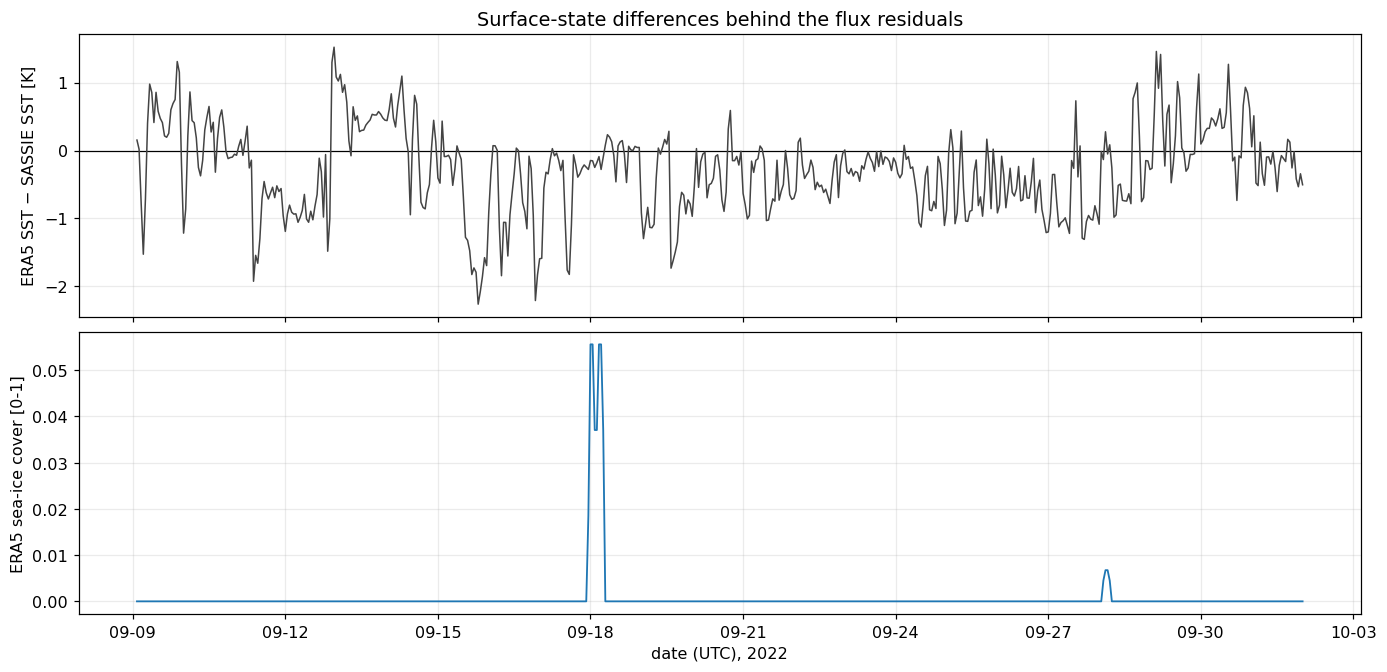

In [16]:

sst_bias_k = hourly["era5_sst"] - (hourly["sst_c"] + FREEZING_POINT_K)
print(f"ERA5 SST minus SASSIE bulk SST: mean {sst_bias_k.mean():+.2f} K, "
      f"median {sst_bias_k.median():+.2f} K, RMS {np.sqrt((sst_bias_k ** 2).mean()):.2f} K")

has_ice = hourly["era5_siconc"] > 0.01
print(f"\nmatched hours with ERA5 sea ice in the cell: {int(has_ice.sum())} "
      f"of {len(hourly)} ({has_ice.mean():.1%})")

if has_ice.any() and (~has_ice).any():
    rows = {}
    for column, label in [("swd_w_m2", "SW down"), ("lwd_w_m2", "LW down"),
                          ("sh_up_w_m2", "sensible"), ("lh_up_w_m2", "latent")]:
        rows[label] = {
            "bias, ice-free cells": hourly.loc[~has_ice, f"resid_{column}"].mean(),
            "bias, cells with ice": hourly.loc[has_ice, f"resid_{column}"].mean(),
        }
    display(pd.DataFrame(rows).T.round(1))

fig, (ax_sst, ax_ice) = plt.subplots(2, 1, figsize=(12.5, 6.0), sharex=True,
                                     constrained_layout=True)
ax_sst.axhline(0.0, color="k", lw=0.8)
ax_sst.plot(hourly.index, sst_bias_k, lw=1.0, color=C_RESID)
ax_sst.set_ylabel("ERA5 SST $-$ SASSIE SST [K]")
ax_sst.set_title("Surface-state differences behind the flux residuals")

ax_ice.plot(hourly.index, hourly["era5_siconc"], lw=1.2, color=C_ERA5)
ax_ice.set_ylabel("ERA5 sea-ice cover [0-1]")
ax_ice.set_xlabel("date (UTC), 2022")
ax_ice.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax_ice.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.savefig(FIG_DIR / "era5_vs_sassie_surface_state.png", bbox_inches="tight")
plt.show()

## 8. Saved output

All figures are written to `figures/` at 200 dpi:

| File | Content |
| --- | --- |
| `sassie_era5_collocation_map.png` | Ship track and the ERA5 cells matched to it |
| `era5_vs_sassie_shortwave.png` | Downwelling shortwave, comparison + residual |
| `era5_vs_sassie_longwave.png` | Downwelling longwave, comparison + residual |
| `era5_vs_sassie_sensible.png` | Sensible heat flux, comparison + residual |
| `era5_vs_sassie_latent.png` | Latent heat flux, comparison + residual |
| `era5_vs_sassie_net_longwave.png` | Supplement: net longwave in the Figure 8c convention |
| `era5_vs_sassie_scatter.png` | All four fluxes as ERA5-vs-SASSIE scatter with 1:1 line |
| `era5_vs_sassie_surface_state.png` | SST difference and ERA5 sea-ice cover along the track |

### Reading the result

The comparison is against a single ship, over 23 days, in one Beaufort Sea box, so it constrains
ERA5 *there and then*. Three limits are worth carrying forward:

1. **ERA5 is not independent of these observations.** ERA5 assimilates conventional surface and
   satellite data; near-surface fields over the Beaufort in 2022 are constrained by the same
   synoptic observing system the ship sat inside. Agreement is therefore a weaker endorsement than
   it looks, and disagreement is correspondingly more informative.
2. **A 0.25 deg cell is not a ship.** ERA5 reports a ~28 x 9 km area average; the ship is a point.
   Part of the cRMSD is representativeness, not model error, and none of it can be separated out
   with one platform.
3. **The turbulent comparison is model against model.** SASSIE's sensible and latent fluxes are
   COARE 3.5 bulk estimates driven by measured wind, temperature and SST, not eddy-covariance
   fluxes. What that comparison tests is whether ERA5's surface layer scheme and near-surface state
   agree with COARE driven by shipboard measurements - a useful test, but not a validation against
   ground truth. The radiation comparison, by contrast, is against direct measurements.